In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.model_selection import train_test_split
import mlflow
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

c:\Users\Admin\Desktop\Project\Credit_Risk\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv('credit_data.csv')

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df.drop(columns=['Unnamed: 0'],inplace=True)

<Axes: ylabel='Frequency'>

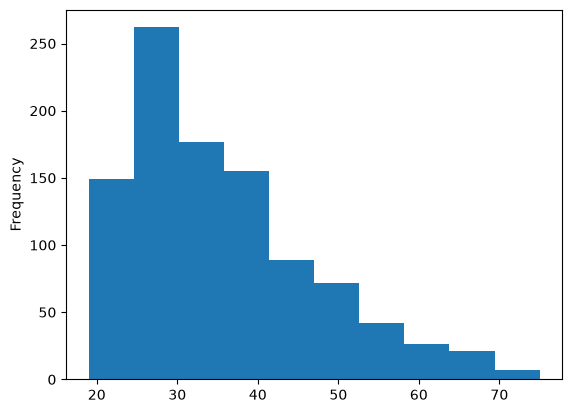

In [7]:
df.Age.plot(kind='hist')

In [8]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [9]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [11]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,1000,2,good,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df =df.dropna().reset_index(drop=True)

In [14]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


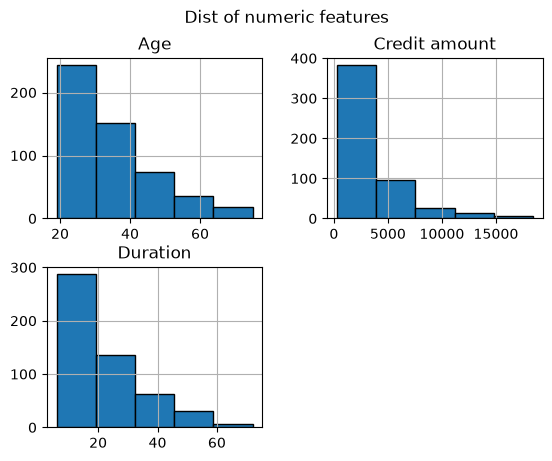

In [15]:
df[["Age","Credit amount","Duration"]].hist(bins=5,edgecolor='black')
plt.suptitle("Dist of numeric features",fontsize=12)
plt.show()

In [16]:
df.query("Duration >= 60 & Job == 2")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [17]:
cats = ["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

C:\Users\Admin\AppData\Local\Temp\ipykernel_372\1370780775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette="Blues",order=df[col].value_counts().index)
C:\Users\Admin\AppData\Local\Temp\ipykernel_372\1370780775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette="Blues",order=df[col].value_counts().index)
C:\Users\Admin\AppData\Local\Temp\ipykernel_372\1370780775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=col,palette="Blues",order=df[col].value_counts().index)
C:\Users\A

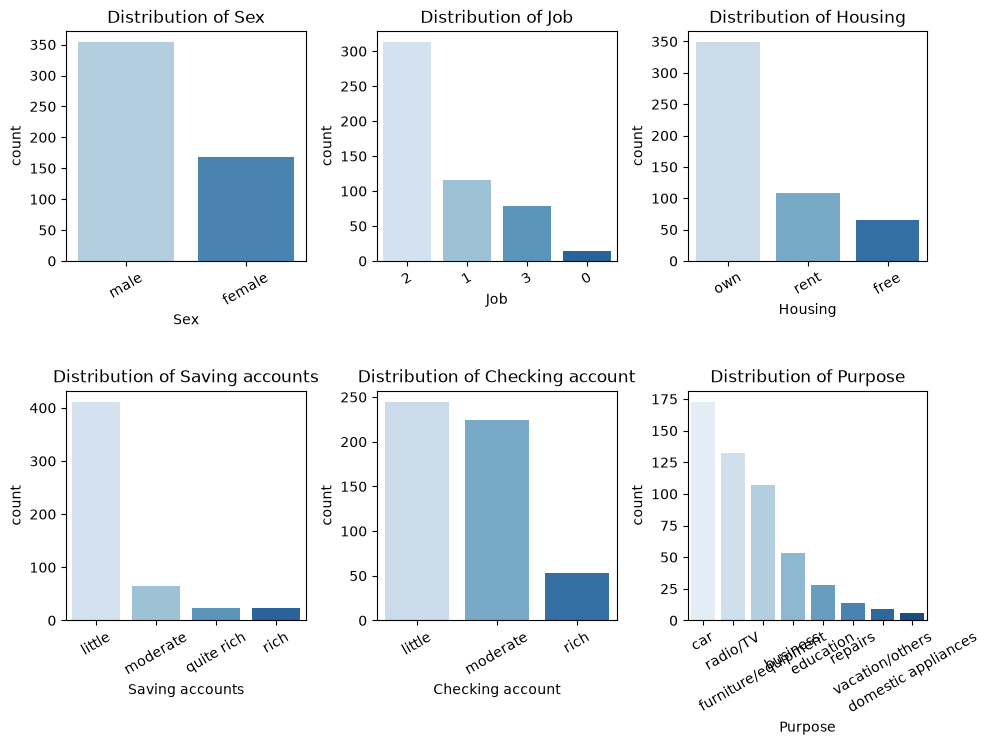

In [18]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cats):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,palette="Blues",order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [19]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


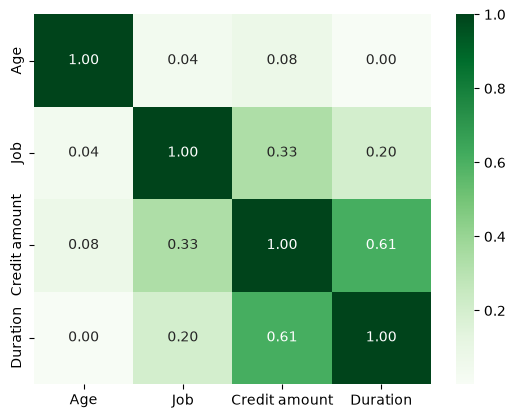

In [20]:
sns.heatmap(corr,annot=True,cmap="Greens",fmt=".2f")
plt.show()

In [21]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [22]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [23]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


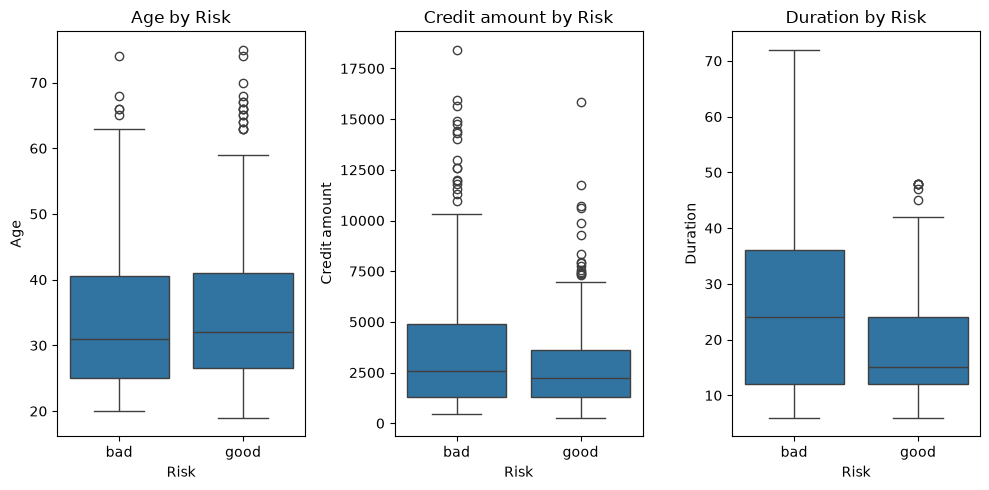

In [24]:
plt.figure(figsize=(10,5))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=col)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [25]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


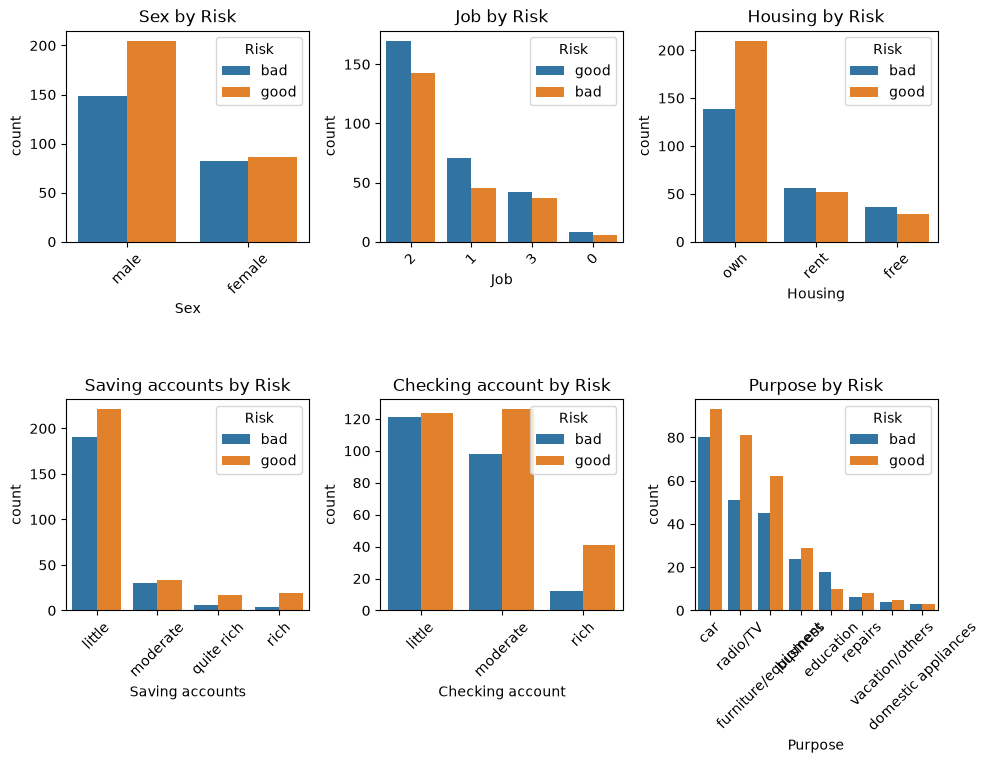

In [26]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cats):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue="Risk",order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [28]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration']
target="Risk"

In [29]:
data = df[features + [target]].copy()
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               522 non-null    int64 
 1   Sex               522 non-null    object
 2   Job               522 non-null    int64 
 3   Housing           522 non-null    object
 4   Saving accounts   522 non-null    object
 5   Checking account  522 non-null    object
 6   Credit amount     522 non-null    int64 
 7   Duration          522 non-null    int64 
 8   Risk              522 non-null    object
dtypes: int64(4), object(5)
memory usage: 36.8+ KB


In [31]:
data["Sex"] = data["Sex"].map({"male":1, "female":0})

data["Risk"] = data["Risk"].map({"good":1, "bad":0})

data["Saving accounts"] = data["Saving accounts"].map({
    "little":0,
    "moderate":1,
    "quite rich":2,
    "rich":3
})

data["Checking account"] = data["Checking account"].map({
    "little":0,
    "moderate":1,
    "rich":2
})

data = pd.get_dummies(data, columns=["Housing"], drop_first=True)
data[['Housing_own', 'Housing_rent']] = (
    data[['Housing_own', 'Housing_rent']].astype(int)
)

In [32]:
data.head()

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Risk,Housing_own,Housing_rent
0,22,0,2,0,1,5951,48,0,1,0
1,45,1,2,0,0,7882,42,1,0,0
2,53,1,2,0,0,4870,24,0,0,0
3,35,1,3,0,1,6948,36,1,0,1
4,28,1,3,0,1,5234,30,0,1,0


In [33]:
data["Risk"].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [34]:
x = data.drop(columns='Risk')
y = data['Risk']

In [35]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=20,stratify=y,test_size=0.20)

In [37]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(417, 9)
(105, 9)
(417,)
(105,)


In [38]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

In [46]:
def train_and_log(model,param_grid,model_name,x_train,y_train,x_test,y_test,scoring="roc_auc"):

    mlflow.set_tracking_uri("./mlruns")

    with mlflow.start_run(run_name=model_name):

        # Hyperparameter Tuning
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )

        grid.fit(x_train, y_train)

        best_model = grid.best_estimator_

        # Predictions
        y_pred = best_model.predict(x_test)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Log Best Params
        mlflow.log_params(grid.best_params_)

        # Log CV Score
        mlflow.log_metric("best_cv_score", grid.best_score_)

        # Log Test Metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)

        # ROC AUC
        if hasattr(best_model, "predict_proba"):
            y_prob = best_model.predict_proba(x_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
            mlflow.log_metric("roc_auc", auc)

        # Classification Report
        report = classification_report(y_test, y_pred)

        with open("classification_report.txt", "w") as f:
            f.write(report)

        mlflow.log_artifact("classification_report.txt")

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(cm)
        disp.plot()

        plt.savefig("confusion_matrix.png")
        plt.close()

        mlflow.log_artifact("confusion_matrix.png")

        # Feature Importance
        if hasattr(best_model, "feature_importances_"):

            feature_imp = dict(
                zip(
                    x_train.columns,
                    best_model.feature_importances_
                )
            )

            mlflow.log_dict(
                feature_imp,
                "feature_importance.json"
            )

        # Save Model
        if isinstance(best_model, XGBClassifier):
            mlflow.xgboost.log_model(
                best_model,
                name="model"
            )
        else:
            mlflow.sklearn.log_model(
                best_model,
                name="model"
            )

        print(f"\n{model_name}")
        print("Best Params:", grid.best_params_)
        print("Best CV Score:", round(grid.best_score_, 4))
        print("Test Accuracy:", round(acc, 4))

        return best_model

In [47]:
dt_params = {
    "max_depth": [3, 5, 7, 10,None],
    "min_samples_split": [2, 5, 10],
    "random_state": [10,20,30,40,42,50]
}

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_leaf" : [1,2,4],
    "min_samples_split" : [2,5,10],
    "random_state": [10,20,30,40,42,50]
}

et_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15,None],
    "min_samples_leaf" : [1,2,4],
    "min_samples_split" : [2,5,10],
    "random_state": [10,20,30,40,42,50]
}

xgb_params = {
    "n_estimators": [100, 200,300],
    "max_depth": [3, 5, 7,9],
    "learning_rate": [0.01, 0.1,0.2],
    "subsample" : [0.7,1],
    "colsample_bytree" : [0.7,1],
    "random_state": [10,20,30,40,42,50]
}

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "random_state": [10,20,30,40,42,50,52]
}



In [48]:
dt_model = train_and_log(
    DecisionTreeClassifier(class_weight='balanced'),dt_params,"DecisionTree",x_train,y_train,x_test,y_test
)

rf_model = train_and_log(RandomForestClassifier(class_weight='balanced'),rf_params,"RandomForest",x_train,y_train,x_test,y_test
)

et_model = train_and_log(ExtraTreesClassifier(class_weight='balanced'),et_params,"ExtraTrees",x_train,y_train,x_test,y_test)

xgb_model = train_and_log(XGBClassifier(scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),eval_metric = "auc"),xgb_params,"XGBoost",x_train,y_train,x_test,y_test)

lr_model = train_and_log(LogisticRegression(random_state=52),lr_params,"LogisticRegression",x_train,y_train,x_test,y_test)


DecisionTree
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'random_state': 50}
Best CV Score: 0.6043
Test Accuracy: 0.6

RandomForest
Best Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100, 'random_state': 30}
Best CV Score: 0.6793
Test Accuracy: 0.6286

ExtraTrees
Best Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200, 'random_state': 20}
Best CV Score: 0.6732
Test Accuracy: 0.6095

XGBoost
Best Params: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'random_state': 30, 'subsample': 0.7}
Best CV Score: 0.6935
Test Accuracy: 0.7143


c:\Users\Admin\Desktop\Project\Credit_Risk\venv312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



LogisticRegression
Best Params: {'C': 0.1, 'penalty': 'l2', 'random_state': 10, 'solver': 'liblinear'}
Best CV Score: 0.683
Test Accuracy: 0.6381


In [39]:
xgb_model = joblib.load("xgb_model.pkl")

In [40]:
xgb_model.predict(x_test)

array([1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0])

In [41]:
y_pred = pd.DataFrame(
    xgb_model.predict(x_test),
    index=x_test.index,
    columns=["Predicted"]
)

results = x_test.copy()

results["Actual"] = y_test
results["Predicted"] = xgb_model.predict(x_test)

results

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Housing_own,Housing_rent,Actual,Predicted
266,26,1,2,0,2,2687,15,0,1,1,1
80,27,1,3,0,0,3416,27,1,0,1,0
475,39,1,3,0,0,3345,24,0,1,0,1
208,31,0,2,0,0,1957,6,1,0,1,1
192,23,1,1,0,1,1246,24,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
505,22,1,2,1,1,1514,15,1,0,1,1
10,32,0,1,1,0,1282,24,1,0,0,0
5,25,0,2,0,1,1295,12,0,1,0,0
302,27,0,2,0,1,2930,12,1,0,1,1


In [42]:
confusion_matrix(y_test,y_pred)

array([[33, 13],
       [17, 42]])

In [43]:
(33+42)/(33+42+17+13) * 100

71.42857142857143

In [44]:
joblib.dump(xgb_model,"xgb_model.pkl")

['xgb_model.pkl']

In [45]:
x_test.head(3)

,Age,Sex,Job,Saving accounts,Checking account,Credit amount,Duration,Housing_own,Housing_rent
266,26,1,2,0,2,2687,15,0,1
80,27,1,3,0,0,3416,27,1,0
475,39,1,3,0,0,3345,24,0,1


In [46]:
y_test.head(3)

266    1
80     1
475    0
Name: Risk, dtype: int64

In [47]:
from scipy.stats import ks_2samp

In [48]:
auc = roc_auc_score(y_test, y_pred)

gini = 2 * auc - 1

print("AUC:", auc)
print("Gini:", gini)

AUC: 0.7146278555637435
Gini: 0.42925571112748706


In [49]:
from scipy.stats import ks_2samp
xgb_model = joblib.load("xgb_model.pkl")

y_prob = xgb_model.predict_proba(x_test)[:, 1]

good_scores = y_prob[y_test == 1]
bad_scores = y_prob[y_test == 0]

ks_stat, p_value = ks_2samp(good_scores, bad_scores)

print(f"KS Statistic: {ks_stat:.4f}")
print(f"KS Percentage: {ks_stat*100:.2f}%")

KS Statistic: 0.4293
KS Percentage: 42.93%


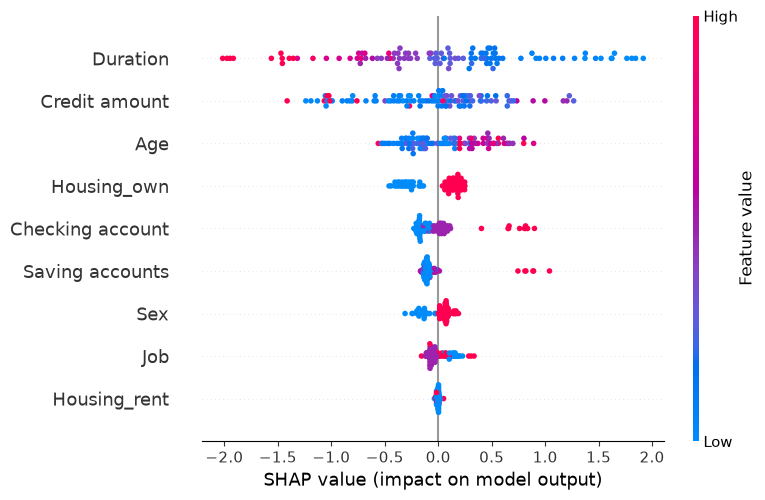

In [50]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(x_test)

shap.summary_plot(
    shap_values,
    x_test
)

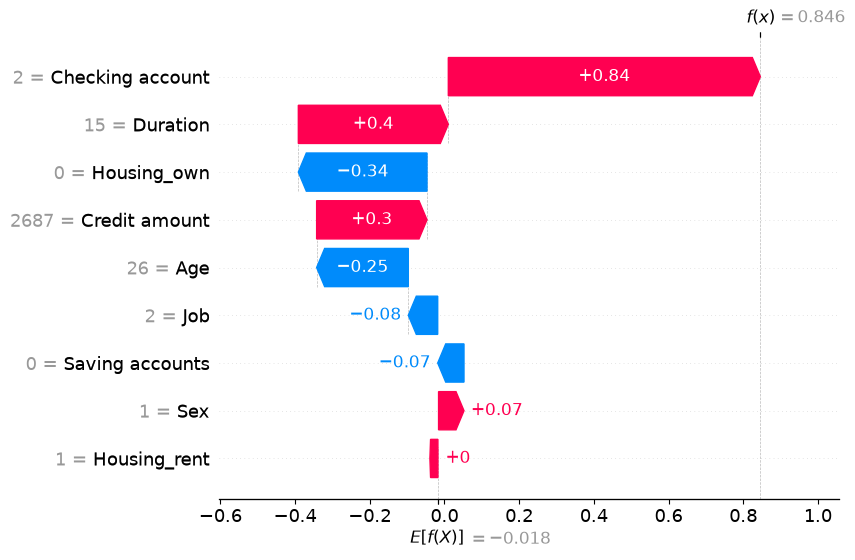

In [59]:
import shap

explainer = shap.TreeExplainer(xgb_model)

customer = x_test.iloc[[0]]

shap_values = explainer.shap_values(customer)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=customer.iloc[0],
        feature_names=customer.columns
    )
)